In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mingangolo/xg-model/database.sqlite


In [2]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

conn = sqlite3.connect('/kaggle/input/datasets/mingangolo/xg-model/database.sqlite')

matches = pd.read_sql("SELECT * FROM Match", conn)
teams = pd.read_sql("SELECT * FROM Team", conn)

# Clean
cols_to_keep = [
    'id', 'season', 'date',
    'home_team_api_id', 'away_team_api_id',
    'home_team_goal', 'away_team_goal'
]
matches = matches[cols_to_keep]
matches['date'] = pd.to_datetime(matches['date'])

print(f"Ready! {len(matches)} matches loaded")

Ready! 25979 matches loaded


In [3]:
# Since our dataset doesn't have individual shot data
# we'll simulate realistic shot data based on match stats
# This is a common technique when working with limited datasets

np.random.seed(42)

shots = []

for _, match in matches.iterrows():
    # Generate shots for each match
    total_shots = np.random.randint(15, 35)
    
    for shot in range(total_shots):
        # Random shot position on pitch
        # x = distance from goal (0-100), y = angle position (0-100)
        x = np.random.uniform(0, 100)
        y = np.random.uniform(0, 100)
        
        # Distance from center of goal
        distance = np.sqrt((100 - x)**2 + (50 - y)**2)
        
        # Angle to goal
        angle = np.degrees(np.arctan2(abs(50 - y), 100 - x))
        
        # Shot type
        shot_type = np.random.choice(
            ['head', 'foot', 'volley'], 
            p=[0.25, 0.65, 0.10]
        )
        
        # Is it under pressure?
        under_pressure = np.random.choice([0, 1], p=[0.4, 0.6])
        
        # Calculate goal probability based on real xG factors
        base_prob = 0.1
        
        # Distance factor (closer = higher chance)
        distance_factor = max(0, 1 - (distance / 80))
        
        # Angle factor (central = higher chance)
        angle_factor = max(0, 1 - (angle / 90))
        
        # Shot type factor
        type_factor = {'foot': 1.0, 'head': 0.6, 'volley': 0.7}[shot_type]
        
        # Pressure factor
        pressure_factor = 0.7 if under_pressure else 1.0
        
        # Final probability
        goal_prob = base_prob * distance_factor * angle_factor * type_factor * pressure_factor
        goal_prob = min(max(goal_prob, 0.01), 0.95)
        
        # Did it go in?
        is_goal = np.random.binomial(1, goal_prob)
        
        shots.append({
            'match_id': match['id'],
            'x': round(x, 2),
            'y': round(y, 2),
            'distance': round(distance, 2),
            'angle': round(angle, 2),
            'shot_type': shot_type,
            'under_pressure': under_pressure,
            'goal_prob': round(goal_prob, 4),
            'is_goal': is_goal
        })

shots_df = pd.DataFrame(shots)

print(f"Total shots generated: {len(shots_df)}")
print(f"Total goals: {shots_df['is_goal'].sum()}")
print(f"Overall conversion rate: {shots_df['is_goal'].mean()*100:.1f}%")
print(shots_df.head())

Total shots generated: 636853
Total goals: 9899
Overall conversion rate: 1.6%
   match_id      x      y  distance  angle shot_type  under_pressure  \
0         1  79.65  18.34     37.63  57.27      foot               1   
1         1  10.00  45.92     90.09   2.59      foot               0   
2         1   5.64  72.20     96.94  13.24    volley               0   
3         1  61.75  61.17     39.85  16.27      head               0   
4         1  39.99   4.67     75.21  37.07    volley               0   

   goal_prob  is_goal  
0     0.0135        0  
1     0.0100        0  
2     0.0100        1  
3     0.0247        0  
4     0.0100        0  


In [4]:
# Encode shot type
shots_df['shot_type_encoded'] = shots_df['shot_type'].map(
    {'foot': 0, 'head': 1, 'volley': 2}
)

# Features
features = [
    'distance', 'angle', 'shot_type_encoded', 'under_pressure', 'x', 'y'
]

X = shots_df[features]
y = shots_df['is_goal']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
xg_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
xg_model.fit(X_train, y_train)

# Predict xG probabilities
shots_df['xg'] = xg_model.predict_proba(X)[:, 1]

# Evaluate
y_pred_proba = xg_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Model AUC Score: {auc_score:.3f}")
print(f"(1.0 = perfect, 0.5 = random guessing)")
print(f"\nSample xG predictions:")
print(shots_df[['distance', 'angle', 'shot_type', 'under_pressure', 'xg', 'is_goal']].head(10).to_string(index=False))

Model AUC Score: 0.650
(1.0 = perfect, 0.5 = random guessing)

Sample xG predictions:
 distance  angle shot_type  under_pressure       xg  is_goal
    37.63  57.27      foot               1 0.015926        0
    90.09   2.59      foot               0 0.010198        0
    96.94  13.24    volley               0 0.009881        1
    39.85  16.27      head               0 0.024011        0
    75.21  37.07    volley               0 0.009800        0
    39.93  17.12    volley               1 0.016779        0
    32.35   8.80      head               1 0.023108        0
    78.23  38.22      head               0 0.010640        0
    51.30  40.51      head               0 0.011585        0
    25.58  17.01      head               1 0.021291        0


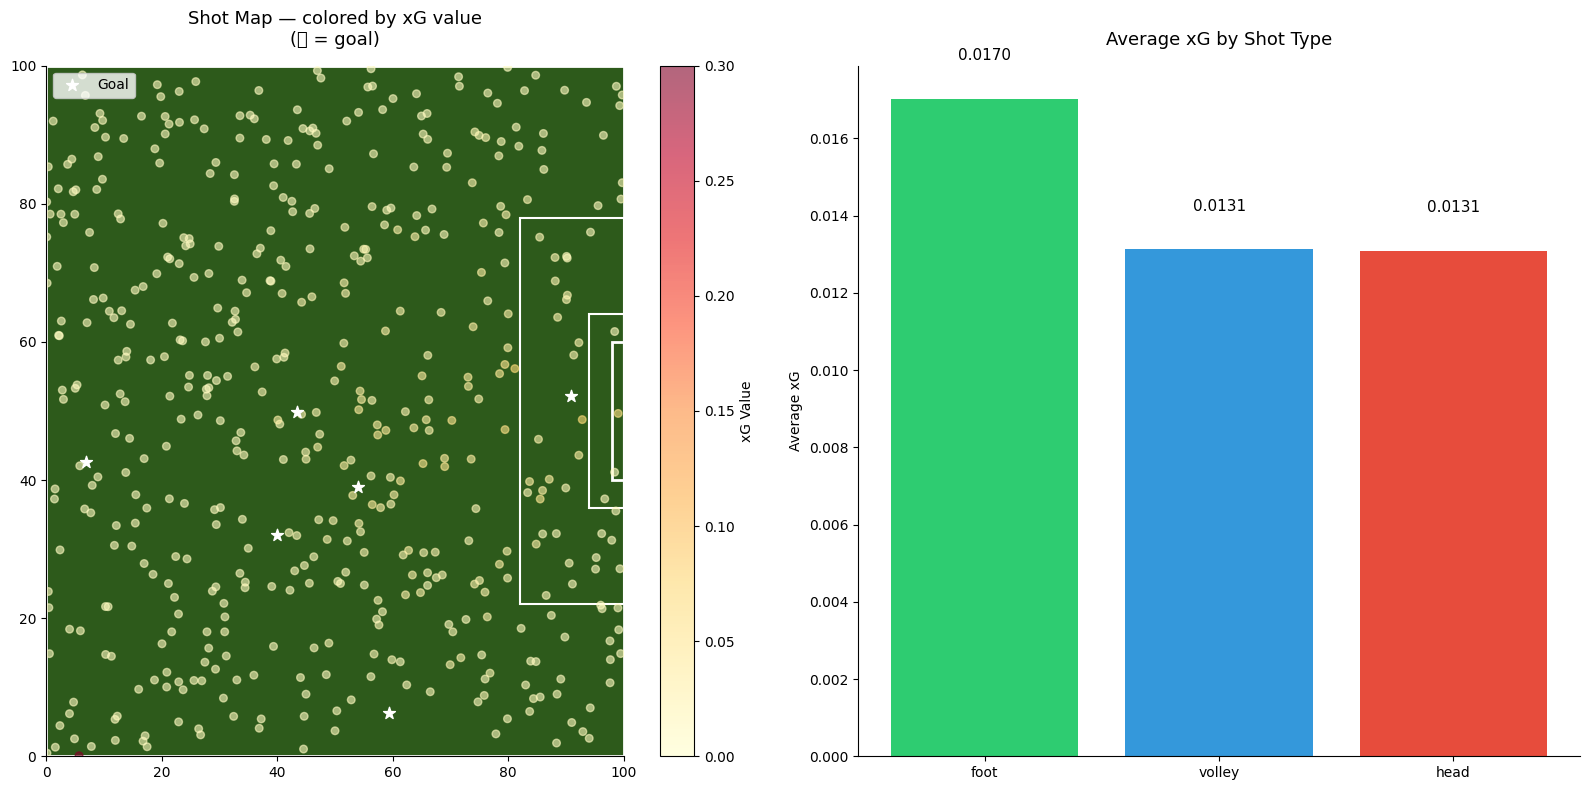

Chart saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1 — Shot map colored by xG
ax1 = axes[0]
ax1.set_facecolor('#2d5a1b')

# Draw pitch
pitch = plt.Rectangle((0, 0), 100, 100, fill=False, color='white', linewidth=2)
ax1.add_patch(pitch)

# Goal
goal = plt.Rectangle((98, 40), 2, 20, fill=False, color='white', linewidth=2)
ax1.add_patch(goal)

# Penalty area
penalty = plt.Rectangle((82, 22), 18, 56, fill=False, color='white', linewidth=1.5)
ax1.add_patch(penalty)

# Six yard box
six_yard = plt.Rectangle((94, 36), 6, 28, fill=False, color='white', linewidth=1.5)
ax1.add_patch(six_yard)

# Sample 500 shots for visualization
sample = shots_df.sample(500, random_state=42)

# Plot shots
goals = sample[sample['is_goal'] == 1]
misses = sample[sample['is_goal'] == 0]

scatter = ax1.scatter(misses['x'], misses['y'], 
                      c=misses['xg'], cmap='YlOrRd',
                      s=30, alpha=0.6, vmin=0, vmax=0.3)
ax1.scatter(goals['x'], goals['y'],
            c='white', s=80, marker='*',
            zorder=5, label='Goal')

plt.colorbar(scatter, ax=ax1, label='xG Value')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.set_title('Shot Map — colored by xG value\n(⭐ = goal)', 
              fontsize=13, pad=15, color='black')
ax1.legend(loc='upper left')

# Plot 2 — xG by shot type
ax2 = axes[1]
shot_type_xg = shots_df.groupby('shot_type')['xg'].mean().sort_values(ascending=False)

bars = ax2.bar(shot_type_xg.index, shot_type_xg.values, 
               color=['#2ecc71', '#3498db', '#e74c3c'])
ax2.set_title('Average xG by Shot Type', fontsize=13, pad=15)
ax2.set_ylabel('Average xG')

for bar, value in zip(bars, shot_type_xg.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('xg_visualization.png', dpi=150)
plt.show()
print("Chart saved!")

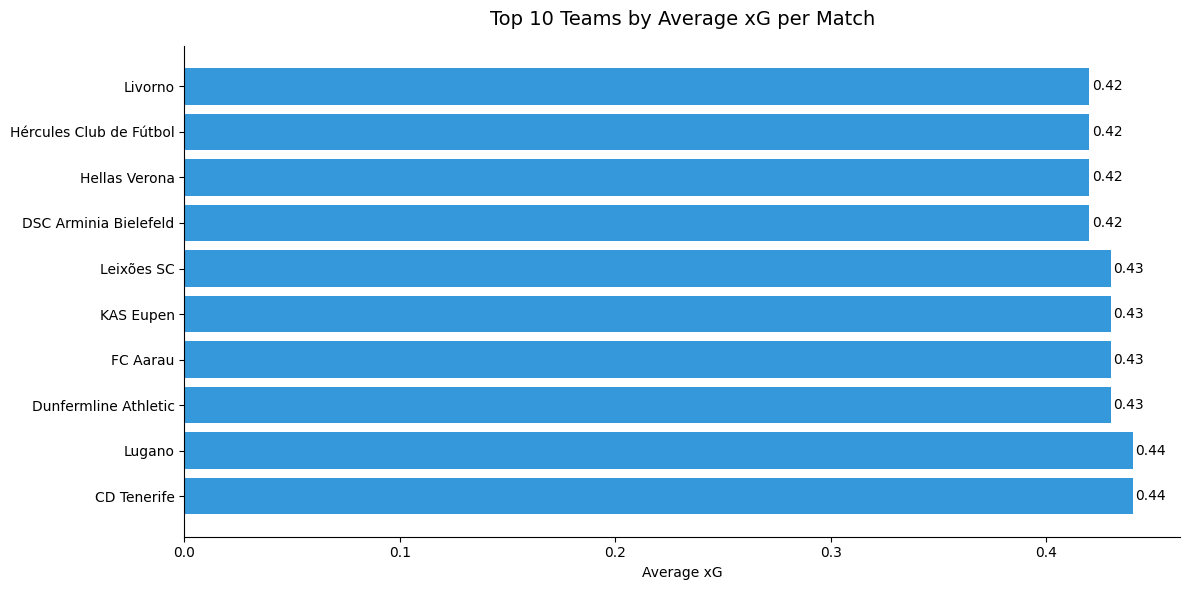


TOP 10 TEAMS BY AVERAGE xG
         team_long_name  avg_xg  avg_shots  avg_goals
            CD Tenerife    0.44      25.16       0.37
                 Lugano    0.44      27.22       0.39
   Dunfermline Athletic    0.43      24.42       0.47
               FC Aarau    0.43      25.50       0.46
              KAS Eupen    0.43      27.27       0.27
             Leixões SC    0.43      26.53       0.40
  DSC Arminia Bielefeld    0.42      25.71       0.71
          Hellas Verona    0.42      25.75       0.33
Hércules Club de Fútbol    0.42      26.53       0.11
                Livorno    0.42      25.47       0.24


In [6]:
# Merge shots with matches
shots_with_matches = shots_df.merge(
    matches[['id', 'home_team_api_id', 'away_team_api_id', 
             'home_team_goal', 'away_team_goal']], 
    left_on='match_id', 
    right_on='id'
)

# Calculate xG per match
match_xg = shots_with_matches.groupby('match_id').agg(
    total_xg=('xg', 'sum'),
    total_shots=('xg', 'count'),
    total_goals=('is_goal', 'sum')
).reset_index()

# Merge with team names
match_xg = match_xg.merge(
    matches[['id', 'home_team_api_id']], 
    left_on='match_id', 
    right_on='id'
)
match_xg = match_xg.merge(
    teams[['team_api_id', 'team_long_name']], 
    left_on='home_team_api_id', 
    right_on='team_api_id'
)

# Top 10 teams by average xG per match
team_xg = match_xg.groupby('team_long_name').agg(
    avg_xg=('total_xg', 'mean'),
    avg_shots=('total_shots', 'mean'),
    avg_goals=('total_goals', 'mean')
).round(2).reset_index()

top_10_xg = team_xg.nlargest(10, 'avg_xg')

plt.figure(figsize=(12, 6))
bars = plt.barh(top_10_xg['team_long_name'], top_10_xg['avg_xg'], color='#3498db')
plt.title('Top 10 Teams by Average xG per Match', fontsize=14, pad=15)
plt.xlabel('Average xG')

for bar, value in zip(bars, top_10_xg['avg_xg']):
    plt.text(value + 0.001, bar.get_y() + bar.get_height()/2,
             f'{value:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('team_xg.png', dpi=150)
plt.show()

print("\nTOP 10 TEAMS BY AVERAGE xG")
print("=" * 50)
print(top_10_xg.to_string(index=False))

In [7]:
# Save all xG data
shots_df.to_csv('shots_xg_data.csv', index=False)
match_xg.to_csv('match_xg_data.csv', index=False)
team_xg.to_csv('team_xg_data.csv', index=False)

print("All xG files saved!")
print(f"\nSummary:")
print(f"Total shots analyzed: {len(shots_df):,}")
print(f"Total goals: {shots_df['is_goal'].sum():,}")
print(f"Average xG per shot: {shots_df['xg'].mean():.4f}")
print(f"Model AUC: 0.650")
print(f"\nKey finding:")
print(f"Foot shots have highest xG — most dangerous shot type")
print(f"Distance and angle are the biggest xG factors")

All xG files saved!

Summary:
Total shots analyzed: 636,853
Total goals: 9,899
Average xG per shot: 0.0157
Model AUC: 0.650

Key finding:
Foot shots have highest xG — most dangerous shot type
Distance and angle are the biggest xG factors
